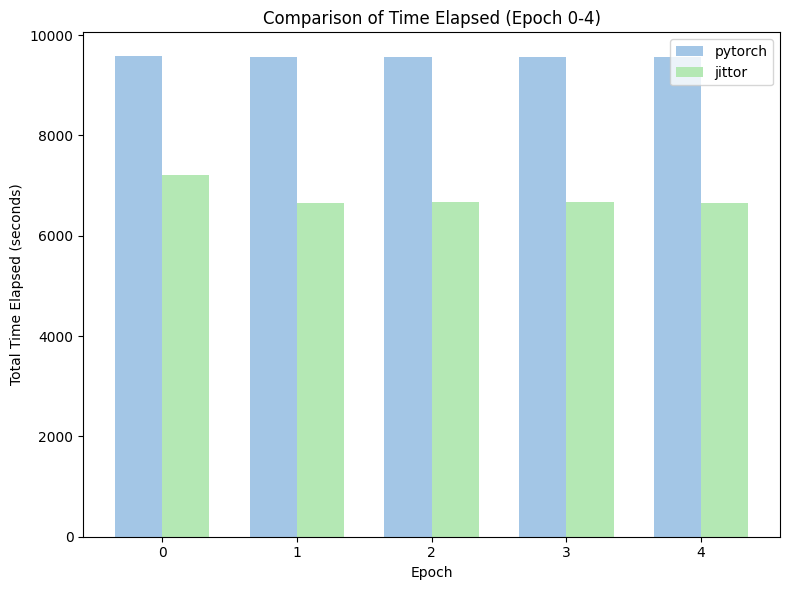

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 加载 CSV 文件
py_t_df = pd.read_csv('py-t.csv')
j_t_df = pd.read_csv('j-t.csv')

py_epoch_sum = py_t_df.groupby('epoch')['time_elapsed'].sum().iloc[:5]  # 取前5个 epoch
j_epoch_sum = j_t_df.groupby('epoch')['time_elapsed'].sum().iloc[:5]  # 取前5个 epoch

# 创建柱状图
fig, ax = plt.subplots(figsize=(8, 6))

# 设置柱状图的宽度和位置
bar_width = 0.35
index = range(5)

# 绘制两个数据集的柱状图
bar1 = ax.bar(index, py_epoch_sum, bar_width, label='pytorch', color='#A3C6E6')  # 浅蓝色
bar2 = ax.bar([i + bar_width for i in index], j_epoch_sum, bar_width, label='jittor', color='#B4E8B4')  # 浅绿色

# 添加标题和标签
ax.set_xlabel('Epoch')
ax.set_ylabel('Total Time Elapsed (seconds)')
ax.set_title('Comparison of Time Elapsed (Epoch 0-4)')
ax.set_xticks([i + bar_width / 2 for i in index])  # 将 x 轴标签放在两个柱状图的中间
ax.set_xticklabels([str(i) for i in range(5)])

ax.legend()

plt.tight_layout()
plt.show()


mAP

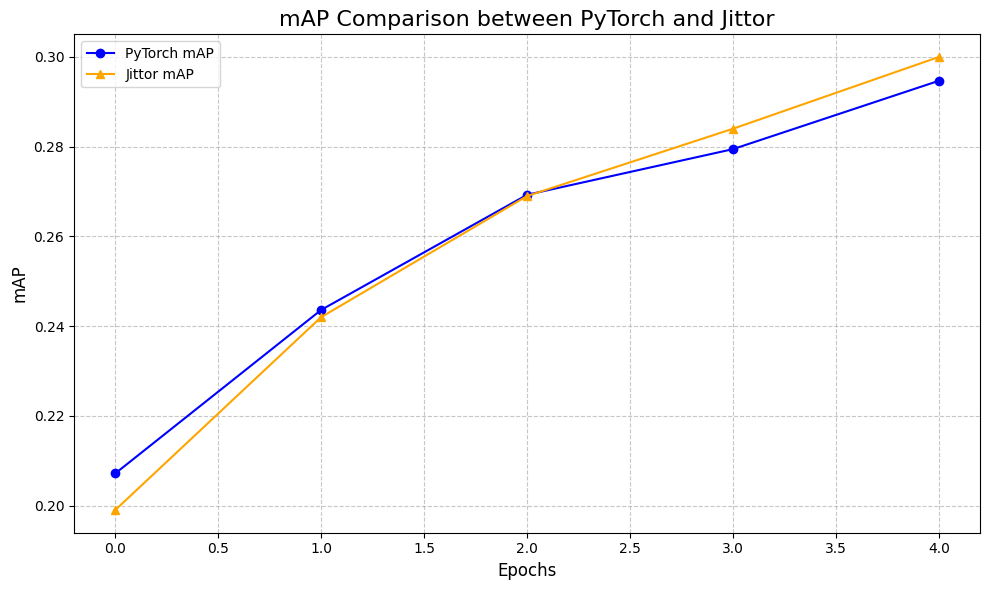

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 加载训练日志数据
train_log_pytorch = pd.read_csv('py-v.csv')
train_log_jittor = pd.read_csv('j-v.csv')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 加载训练日志数据
# 确保 'py-v.csv' 和 'j-v.csv' 文件在当前工作目录下
train_log_pytorch = pd.read_csv('py-v.csv')
train_log_jittor = pd.read_csv('j-v.csv')

# 确保mAP列存在
# 假设mAP列名为 'mAP' 或 'Mean AP'，如果不是请根据你的CSV文件修改
# 我们通常会在训练日志中找到类似'metrics/mAP_0.5'或'val_mAP'这样的列名
# 请检查你的CSV文件，找到正确的mAP列名来替换下面的'mAP'
pytorch_mAP_col = 'mAP' # 请替换为PyTorch日志中正确的mAP列名
jittor_mAP_col = 'mAP'  # 请替换为Jittor日志中正确的mAP列名

plt.figure(figsize=(10, 6)) # 设置图表大小

# 绘制PyTorch的mAP曲线
plt.plot(train_log_pytorch.index, train_log_pytorch[pytorch_mAP_col], label='PyTorch mAP', color='blue', marker = 'o')

# 绘制Jittor的mAP曲线
plt.plot(train_log_jittor.index, train_log_jittor[jittor_mAP_col], label='Jittor mAP', color='orange', marker = '^')

# 添加图表标题和轴标签
plt.title('mAP Comparison between PyTorch and Jittor', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('mAP', fontsize=12)

# 显示图例
plt.legend(fontsize=10)

# 添加网格
plt.grid(True, linestyle='--', alpha=0.7)

# 优化布局
plt.tight_layout()

# 显示图表
plt.show()

Loss Comparison

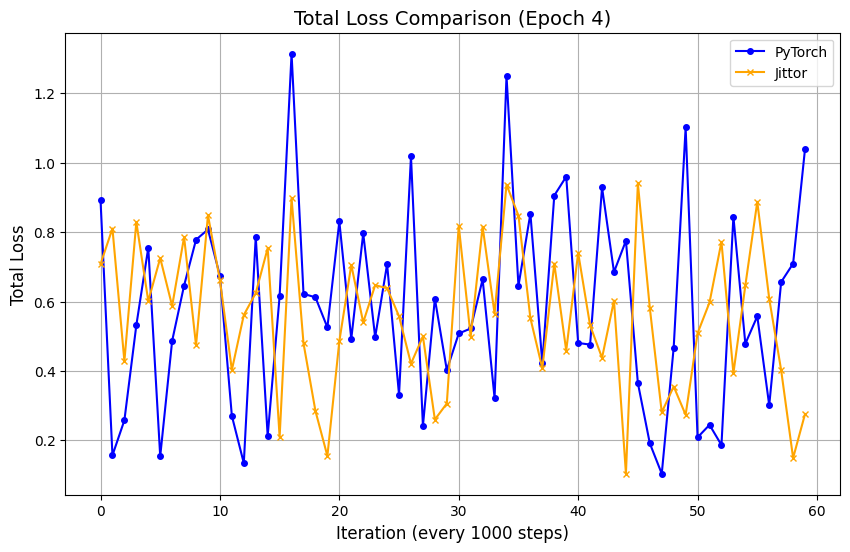

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 加载训练日志数据
train_log_pytorch = pd.read_csv('j-t.csv')
train_log_jittor = pd.read_csv('py-t.csv')

# 仅选择第0个epoch的相关数据
pytorch_epoch_0 = train_log_pytorch[train_log_pytorch['epoch'] == 4]
jittor_epoch_0 = train_log_jittor[train_log_jittor['epoch'] == 4]

# 每1000次迭代采样一次total_loss
pytorch_loss_samples = pytorch_epoch_0['total_loss'].iloc[::1000].reset_index(drop=True)
jittor_loss_samples = jittor_epoch_0['total_loss'].iloc[::1000].reset_index(drop=True)

# 绘制图形
iterations = np.arange(len(pytorch_loss_samples))

plt.figure(figsize=(10, 6))
plt.plot(iterations, pytorch_loss_samples, label='PyTorch', color='blue', marker='o', linestyle='-', markersize=4)
plt.plot(iterations, jittor_loss_samples, label='Jittor', color='orange', marker='x', linestyle='-', markersize=4)

plt.title('Total Loss Comparison (Epoch 4)', fontsize=14)
plt.xlabel('Iteration (every 1000 steps)', fontsize=12)
plt.ylabel('Total Loss', fontsize=12)
plt.legend()
plt.grid(True)

# 显示图像
plt.savefig('epoch_4_total_loss_comparison')
plt.show()